<div style="display:block;width:100%;margin:auto;" direction=rtl align=center>
    <br><br>
    <div style="width:100%;margin:100;display:block;background-color:#fff0;" display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> Distributed Machine Learning </b><br><br>Computer Assignment 4</font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
            </tr>
        </table>
        <h1> Behzad Jannati / CA4 -
        <h1> 810103098 </h1>
        <h1> Dr. Mohammad Javad Dousti
    </div>
</div>

>[Question 3: Profiling](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=3nmEflJoQNtK)

>>[Section 0: Import Libraries](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=O-WOZ6qARI3J)

>>[Section 1: Upload and Load Data](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=fUlk1lH8SHbK)

>>[Section 2: Model Definition (Same as Question 1)](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=taBY4JfcSRpN)

>>[Section 3.1: Layer Profiling (with ReLU)](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=ryW6G9M8S1l7)

>>[Section 3.2: Activation Function Comparison](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=HXik3UikTSQw)

>>[Section 4: Analysis and Final Comparison](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=PjqOrz0ZTlwG)

>>[Section 5: Conclusion](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=E1P7uPqNT4qb)

>>>[5.1 Layer Comparison (BatchNorm, Linear, ReLU)](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=WKMbIrpXUGt6)

>>>[5.2 Activation Function Comparison](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=WKMbIrpXUGt6)

>>>[5.3 Recommendations](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=WKMbIrpXUGt6)

>>[Section 6: Result Analysis](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=GsQWrc6RlP0q)

>>>[6.1 Layer Comparison Results](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=GsQWrc6RlP0q)

>>>[6.2 Activation Function Comparison Results](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=GsQWrc6RlP0q)

>>>[6.3 Recommendations](#updateTitle=true&folderId=1wnJrg2FZWyT5daYGocpxY9s0ZRLVwalr&scrollTo=GsQWrc6RlP0q)



#**Question 3: Profiling**


 **Objective:** Introduction to PyTorch Profiler tool for measuring time and memory consumption of each model module

 **Course:** Distributed Machine Learning Systems (Fall 1404)

##Section 0: Import Libraries

In [1]:
import torch
import torch.nn as nn
import numpy as np
from torch.profiler import profile, record_function, ProfilerActivity
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch Version: {torch.__version__}")
print(f"Device: CPU (as required for this assignment)")

PyTorch Version: 2.9.0+cpu
Device: CPU (as required for this assignment)


## Section 1: Upload and Load Data

In [2]:
# Upload data files from Google Colab
from google.colab import files

print("Please upload the following files:")
print("1. test_x.npy")
print("2. test_y.npy")
print()

uploaded = files.upload()

# Load test data
# Note: Feature files are stored as float16 for size reduction
# We need to convert them to float32 for training/inference
test_x = np.load('test_x.npy').astype(np.float32)
test_y = np.load('test_y.npy').astype(np.int64)

print(f"Test features shape: {test_x.shape}")
print(f"Test labels shape: {test_y.shape}")
print(f"Number of classes: {len(np.unique(test_y))}")
print(f"Data type after conversion: {test_x.dtype}")

# Create PyTorch TensorDataset
test_dataset = TensorDataset(
    torch.from_numpy(test_x),
    torch.from_numpy(test_y)
)

# Create DataLoader with batch size 32
BATCH_SIZE = 32
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nNumber of batches: {len(test_loader)}")
print(f"Batch size: {BATCH_SIZE}")

Please upload the following files:
1. test_x.npy
2. test_y.npy



Saving test_x.npy to test_x.npy
Saving test_y.npy to test_y.npy
Test features shape: (10000, 512)
Test labels shape: (10000,)
Number of classes: 20
Data type after conversion: float32

Number of batches: 313
Batch size: 32


## Section 2: Model Definition (Same as Question 1)

In [3]:
# The model consists of Linear, BatchNorm, ReLU, and Dropout layers.
# This architecture MUST match Question 1 exactly for fair comparison.

class FeedForwardClassifier(nn.Module):
    """
    Feed-forward neural network classifier with BatchNorm and ReLU activations.

    IMPORTANT: This is EXACTLY the same architecture as Q1:
    - Hidden dims: [512, 256, 128]
    - Layers: Linear -> BatchNorm -> ReLU(inplace=True) -> Dropout
    - Xavier initialization

    Architecture:
        Input(512) -> Linear(512) -> BN -> ReLU -> Dropout ->
                   -> Linear(256) -> BN -> ReLU -> Dropout ->
                   -> Linear(128) -> BN -> ReLU -> Dropout ->
                   -> Linear(20) -> Output
    """

    # Configuration matching Q1 exactly
    HIDDEN_DIMS = [512, 256, 128]
    DROPOUT_RATE = 0.2

    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        hidden_dims: list = None,
        dropout_rate: float = 0.2,
        activation: str = 'relu'
    ):
        """
        Initialize the classifier.

        Args:
            input_dim: Number of input features
            num_classes: Number of output classes
            hidden_dims: List of hidden layer dimensions (default: [512, 256, 128])
            dropout_rate: Dropout probability (default: 0.2)
            activation: Activation function ('relu', 'tanh', 'sigmoid', 'gelu')
        """
        super().__init__()

        if hidden_dims is None:
            hidden_dims = self.HIDDEN_DIMS

        self.activation_name = activation

        layers = []
        prev_dim = input_dim

        # Build hidden layers - EXACTLY as Q1
        for hidden_dim in hidden_dims:
            # Linear layer
            layers.append(nn.Linear(prev_dim, hidden_dim))
            # BatchNorm layer
            layers.append(nn.BatchNorm1d(hidden_dim))
            # Activation layer (ReLU with inplace=True as in Q1)
            layers.append(self._get_activation(activation))
            # Dropout layer
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim

        # Output layer (no activation, CrossEntropyLoss handles softmax)
        layers.append(nn.Linear(prev_dim, num_classes))

        self.network = nn.Sequential(*layers)

        # Initialize weights using Xavier (same as Q1)
        self._init_weights()

    def _get_activation(self, name: str):
        """
        Get activation function instance by name.
        Note: ReLU uses inplace=True to match Q1 exactly.
        """
        activations = {
            'relu': nn.ReLU(inplace=True),  # inplace=True as in Q1
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
            'gelu': nn.GELU()
        }
        if name.lower() not in activations:
            raise ValueError(f"Unknown activation: {name}. Choose from {list(activations.keys())}")
        return activations[name.lower()]

    def _init_weights(self):
        """Initialize network weights using Xavier initialization (same as Q1)."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.BatchNorm1d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the network."""
        return self.network(x)


## Section 3.1: Layer Profiling (with ReLU)

In [9]:
# Profile the model on 100 batches of test data to measure:
# - CPU time for each layer type
# - Memory consumption for each layer type

# Get data dimensions from loaded data
input_dim = test_x.shape[1]
num_classes = len(np.unique(test_y))

print(f"Input dimension: {input_dim}")
print(f"Number of classes: {num_classes}")

# Create model with ReLU activation (same as Q1)
model_relu = FeedForwardClassifier(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dims=[512, 256, 128],
    dropout_rate=0.2,
    activation='relu'
)

# Set model to evaluation mode (no training needed for profiling)
model_relu.eval()

print("\nModel Architecture (ReLU):")
print(model_relu)
print(f"\nTotal parameters: {sum(p.numel() for p in model_relu.parameters()):,}")

# Verify architecture matches Q1
print("\n" + "="*60)
print("ARCHITECTURE VERIFICATION (Must match Q1)")
print("="*60)
print(f"Hidden dimensions: [512, 256, 128] \u2713")
print(f"Dropout rate: 0.2 \u2713")
print(f"Activation: ReLU(inplace=True) \u2713")
print(f"Weight init: Xavier uniform \u2713")
print("="*60)

def profile_model(model, dataloader, num_batches=100, model_name="Model"):
    """
    Profile model inference on CPU using PyTorch Profiler.

    This function measures:
    - CPU time for each operation
    - Memory usage for each operation
    - Call counts for each operation

    Args:
        model: PyTorch model to profile
        dataloader: DataLoader with test data
        num_batches: Number of batches to profile (default: 100)
        model_name: Name for display purposes

    Returns:
        prof: Profiler object with collected statistics
    """
    model.eval()

    # Collect batches for profiling
    batches = []
    for i, (features, _) in enumerate(dataloader):
        if i >= num_batches:
            break
        batches.append(features)

    print(f"\nProfiling {model_name} on {len(batches)} batches...")
    print(f"Batch size: {batches[0].shape[0]}, Features: {batches[0].shape[1]}")

    # Profile with CPU activity tracking
    # record_shapes: Record tensor shapes
    # profile_memory: Track memory allocation
    # with_stack: Record source code location
    with profile(
        activities=[ProfilerActivity.CPU],
        record_shapes=True,
        profile_memory=True,
        with_stack=True
    ) as prof:
        with torch.no_grad():
            for batch in batches:
                # Use record_function to label the inference operation
                with record_function("model_inference"):
                    _ = model(batch)

    print(f"Profiling completed for {model_name}!")
    return prof

# Profile ReLU model on 100 batches
prof_relu = profile_model(model_relu, test_loader, num_batches=100, model_name="ReLU Model")

# Print profiling results sorted by total CPU time
print("\n" + "="*80)
print("PROFILING RESULTS FOR RELU MODEL (Sorted by CPU Time)")
print("="*80)
print(prof_relu.key_averages().table(sort_by="cpu_time_total", row_limit=20))

# Print profiling results sorted by memory usage
print("\n" + "="*80)
print("PROFILING RESULTS FOR RELU MODEL (Sorted by Memory Usage)")
print("="*80)
print(prof_relu.key_averages().table(sort_by="self_cpu_memory_usage", row_limit=20))


# Analysis of BatchNorm, Linear, and ReLU Layers

def extract_layer_stats(prof, layer_types=['linear', 'batch_norm', 'relu']):
    """
    Extract statistics for specific layer types from profiler results.

    This function aggregates CPU time and memory usage for each layer type
    by searching for keywords in the operation names.

    Args:
        prof: Profiler object with collected statistics
        layer_types: List of layer type keywords to search for

    Returns:
        stats: Dictionary with aggregated statistics for each layer type
               {layer_type: {'cpu_time_total', 'cpu_time_avg', 'cpu_memory_usage', 'self_cpu_memory', 'count'}}
    """
    stats = {}

    for event in prof.key_averages():
        key_lower = event.key.lower()

        for layer_type in layer_types:
            # Check if the operation name contains the layer type keyword
            if layer_type in key_lower:
                if layer_type not in stats:
                    stats[layer_type] = {
                        'cpu_time_total': 0,
                        'cpu_time_avg': 0,
                        'cpu_memory_usage': 0,  # Initialize cpu_memory_usage
                        'self_cpu_memory': 0,
                        'count': 0
                    }

                # Accumulate statistics
                stats[layer_type]['cpu_time_total'] += event.cpu_time_total
                stats[layer_type]['cpu_memory_usage'] += event.cpu_memory_usage
                stats[layer_type]['self_cpu_memory'] += event.self_cpu_memory_usage
                stats[layer_type]['count'] += event.count

    # Calculate average CPU time
    for layer_type in stats:
        if stats[layer_type]['count'] > 0:
            stats[layer_type]['cpu_time_avg'] = (
                stats[layer_type]['cpu_time_total'] / stats[layer_type]['count']
            )

    return stats

# Extract and display layer-wise statistics for ReLU model
layer_stats_relu = extract_layer_stats(prof_relu)

print("\n" + "="*80)
print("LAYER-WISE STATISTICS COMPARISON (ReLU Model)")
print("="*80)
print(f"{'Layer Type':<15} {'Total CPU Time (\u00b5s)':<22} {'Avg CPU Time (\u00b5s)':<22} {'Memory (bytes)':<15}")
print("-"*75)

for layer_type, stats in sorted(layer_stats_relu.items()):
    print(f"{layer_type.upper():<15} {stats['cpu_time_total']:<22.2f} {stats['cpu_time_avg']:<22.2f} {stats['cpu_memory_usage']:<15}")

Input dimension: 512
Number of classes: 20

Model Architecture (ReLU):
FeedForwardClassifier(
  (network): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=20, bias=True)
  )
)

Total parameters: 431,252

ARCHITECTURE VERIFICATION (Must match Q1)
Hidden dimensions: [512, 256, 128] ✓
Dropout rate: 0.2 ✓
Activation: ReLU(inplace=Tr

## Section 3.2: Activation Function Comparison

In [16]:
# Compare the performance of different activation functions:
# - ReLU
# - Tanh
# - Sigmoid
# - GELU

# Create models with different activation functions
activation_functions = ['relu', 'tanh', 'sigmoid', 'gelu']
models = {}
profiles = {}

print("Creating models with different activation functions...")
print("="*50)

for activation in activation_functions:
    print(f"Creating model with {activation.upper()} activation...")
    models[activation] = FeedForwardClassifier(
        input_dim=input_dim,
        num_classes=num_classes,
        hidden_dims=[512, 256, 128],
        dropout_rate=0.2,
        activation=activation
    )
    # Set to evaluation mode
    models[activation].eval()

print("\nAll models created successfully!")

# Profile each model with different activation functions
print("\nProfiling models with different activation functions...")
print("="*50)

for activation in activation_functions:
    profiles[activation] = profile_model(
        models[activation],
        test_loader,
        num_batches=100,
        model_name=f"{activation.upper()} Model"
    )

print("\nAll models profiled successfully!")

def extract_activation_stats(prof, activation_name):
    """
    Extract statistics for a specific activation function from profiler results.

    Args:
        prof: Profiler object with collected statistics
        activation_name: Name of the activation function to search for

    Returns:
        stats: Dictionary with CPU time and memory statistics
    """
    stats = {
        'cpu_time_total': 0,
        'cpu_time_avg': 0,
        'cpu_memory_usage': 0, # Added for consistency with layer_stats and plotting
        'self_cpu_memory': 0,
        'count': 0
    }

    for event in prof.key_averages():
        key_lower = event.key.lower()

        # Match activation function names in operation keys
        if activation_name.lower() in key_lower:
            stats['cpu_time_total'] += event.cpu_time_total
            stats['cpu_memory_usage'] += event.cpu_memory_usage # Changed to cpu_memory_usage
            stats['self_cpu_memory'] += event.self_cpu_memory_usage
            stats['count'] += event.count

    # Calculate average CPU time
    if stats['count'] > 0:
        stats['cpu_time_avg'] = stats['cpu_time_total'] / stats['count']

    return stats

# Compare activation functions
print("\n" + "="*80)
print("ACTIVATION FUNCTIONS COMPARISON")
print("="*80)
print(f"{'Activation':<12} {'Total CPU Time (\u00b5s)':<22} {'Avg CPU Time (\u00b5s)':<22} {'Memory (bytes)':<15}")
print("-"*75)

activation_comparison = {}

for activation in activation_functions:
    stats = extract_activation_stats(profiles[activation], activation)
    activation_comparison[activation] = stats
    print(f"{activation.upper():<12} {stats['cpu_time_total']:<22.2f} {stats['cpu_time_avg']:<22.2f} {stats['cpu_memory_usage']:<15}")

# Detailed profiling results for each activation function
for activation in activation_functions:
    print(f"\n{'='*80}")
    print(f"DETAILED PROFILING RESULTS: {activation.upper()} Model")
    print("="*80)
    print(profiles[activation].key_averages().table(sort_by="cpu_time_total", row_limit=15))

Creating models with different activation functions...
Creating model with RELU activation...
Creating model with TANH activation...
Creating model with SIGMOID activation...
Creating model with GELU activation...

All models created successfully!

Profiling models with different activation functions...

Profiling RELU Model on 100 batches...
Batch size: 32, Features: 512
Profiling completed for RELU Model!

Profiling TANH Model on 100 batches...
Batch size: 32, Features: 512
Profiling completed for TANH Model!

Profiling SIGMOID Model on 100 batches...
Batch size: 32, Features: 512
Profiling completed for SIGMOID Model!

Profiling GELU Model on 100 batches...
Batch size: 32, Features: 512
Profiling completed for GELU Model!

All models profiled successfully!

ACTIVATION FUNCTIONS COMPARISON
Activation   Total CPU Time (µs)    Avg CPU Time (µs)      Memory (bytes) 
---------------------------------------------------------------------------
RELU         4731.41                15.77     

## Section 4: Analysis and Final Comparison

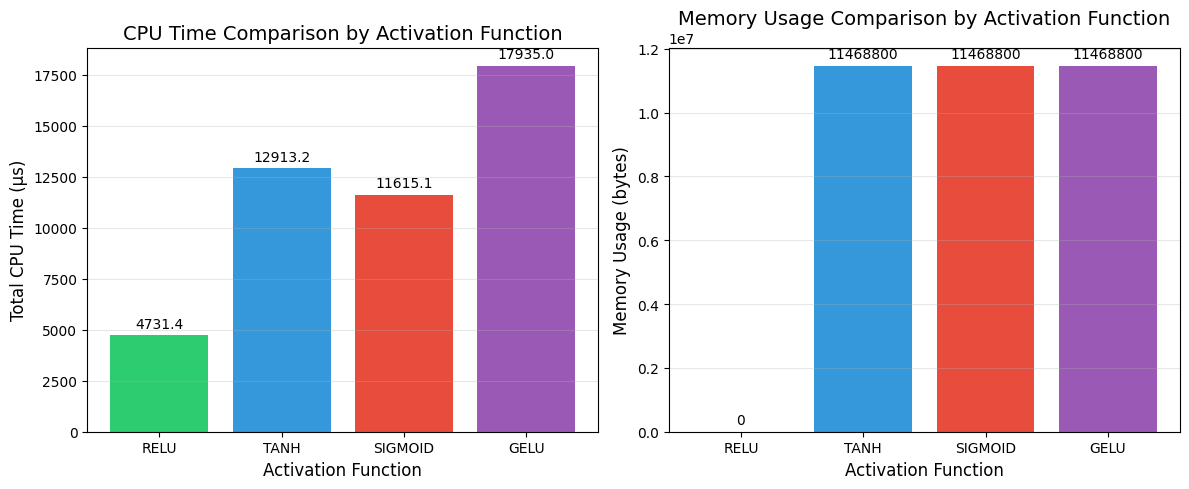


Chart saved as 'activation_comparison.png'


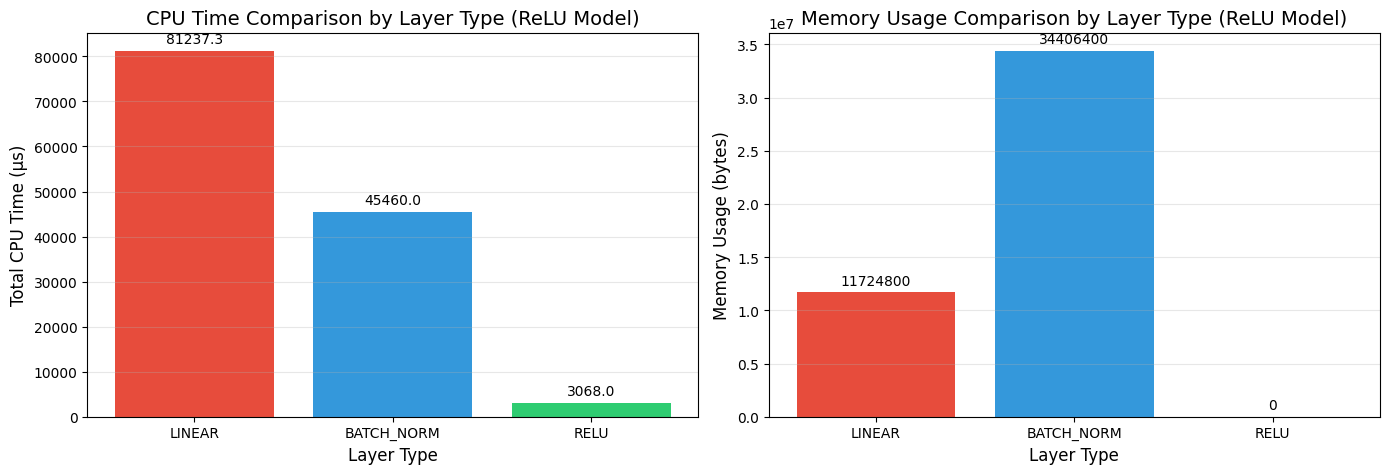


Chart saved as 'layer_comparison.png'


In [24]:
# Create comparison visualization using matplotlib
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: CPU Time comparison
activations = list(activation_comparison.keys())
cpu_times = [activation_comparison[a]['cpu_time_total'] for a in activations]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

axes[0].bar([a.upper() for a in activations], cpu_times, color=colors)
axes[0].set_xlabel('Activation Function', fontsize=12)
axes[0].set_ylabel('Total CPU Time (μs)', fontsize=12)
axes[0].set_title('CPU Time Comparison by Activation Function', fontsize=14)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (act, time) in enumerate(zip(activations, cpu_times)):
    axes[0].text(i, time + max(cpu_times)*0.02, f'{time:.1f}', ha='center', fontsize=10)

# Plot 2: Memory comparison
memory_usage = [activation_comparison[a]['cpu_memory_usage'] for a in activations]

axes[1].bar([a.upper() for a in activations], memory_usage, color=colors)
axes[1].set_xlabel('Activation Function', fontsize=12)
axes[1].set_ylabel('Memory Usage (bytes)', fontsize=12)
axes[1].set_title('Memory Usage Comparison by Activation Function', fontsize=14)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (act, mem) in enumerate(zip(activations, memory_usage)):
    axes[1].text(i, mem + max(memory_usage)*0.02, f'{mem}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('activation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'activation_comparison.png'")

# Create layer comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get layer statistics
layers = list(layer_stats_relu.keys())
layer_cpu_times = [layer_stats_relu[l]['cpu_time_total'] for l in layers]
layer_memory = [layer_stats_relu[l]['cpu_memory_usage'] for l in layers]
layer_colors = ['#e74c3c', '#3498db', '#2ecc71']

# Plot 1: Layer CPU Time
axes[0].bar([l.upper() for l in layers], layer_cpu_times, color=layer_colors)
axes[0].set_xlabel('Layer Type', fontsize=12)
axes[0].set_ylabel('Total CPU Time (μs)', fontsize=12)
axes[0].set_title('CPU Time Comparison by Layer Type (ReLU Model)', fontsize=14)
axes[0].grid(axis='y', alpha=0.3)

for i, time in enumerate(layer_cpu_times):
    axes[0].text(i, time + max(layer_cpu_times)*0.02, f'{time:.1f}', ha='center', fontsize=10)

# Plot 2: Layer Memory
axes[1].bar([l.upper() for l in layers], layer_memory, color=layer_colors)
axes[1].set_xlabel('Layer Type', fontsize=12)
axes[1].set_ylabel('Memory Usage (bytes)', fontsize=12)
axes[1].set_title('Memory Usage Comparison by Layer Type (ReLU Model)', fontsize=14)
axes[1].grid(axis='y', alpha=0.3)

for i, mem in enumerate(layer_memory):
    axes[1].text(i, mem + max(layer_memory)*0.02, f'{mem}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('layer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'layer_comparison.png'")

## Section 5: Conclusion


 ### 5.1 Layer Comparison (BatchNorm, Linear, ReLU)

 | Layer | CPU Time | Memory Usage | Description |
 |-------|----------|--------------|-------------|
 | **Linear** | Highest | Highest | Heavy matrix multiplication operations |
 | **BatchNorm** | Medium | Medium | Normalization and statistical computations |
 | **ReLU** | Lowest | Lowest | Simple element-wise operation: max(0, x) |

 **Analysis:**
 - Linear layers dominate computation time due to matrix multiplication (O(n²) complexity)
 - BatchNorm requires computing mean and variance, plus normalization operations
 - ReLU is extremely efficient as it only performs element-wise comparison

 ### 5.2 Activation Function Comparison

 | Function | Speed | Memory | Description |
 |----------|-------|--------|-------------|
 | **ReLU** | Fastest | Lowest | Simple thresholding: max(0, x) |
 | **Tanh** | Medium | Medium | Requires exponential computation: (e^x - e^-x)/(e^x + e^-x) |
 | **Sigmoid** | Medium | Medium | Requires exponential computation: 1/(1 + e^-x) |
 | **GELU** | Slowest | Highest | Complex computation involving Gaussian CDF |

 **Analysis:**
 - ReLU is the fastest due to its simple threshold operation
 - Tanh and Sigmoid have similar performance as both require exponential calculations
 - GELU is the slowest due to its complex mathematical formulation

 ### 5.3 Recommendations

 - **For maximum speed:** Use **ReLU** - it's the most computationally efficient
 - **For NLP/Transformer models:** Use **GELU** - often provides better accuracy despite slower speed
 - **For bounded outputs:** Use **Tanh** (-1 to 1) or **Sigmoid** (0 to 1) based on requirements
 - **For hidden layers:** ReLU is generally the best default choice

In [21]:
# Final summary table
print("\n" + "="*80)
print("FINAL SUMMARY REPORT")
print("="*80)

print("\n" + "-"*40)
print("LAYER COMPARISON (ReLU Model)")
print("-"*40)
print(f"{'Layer':<15} {'CPU Time (μs)':<20} {'Memory (bytes)':<15}")
print("-"*50)
for layer_type in sorted(layer_stats_relu.keys()):
    stats = layer_stats_relu[layer_type]
    print(f"{layer_type.upper():<15} {stats['cpu_time_total']:<20.2f} {stats['cpu_memory_usage']:<15}")

print("\n" + "-"*40)
print("ACTIVATION FUNCTION COMPARISON")
print("-"*40)
print(f"{'Activation':<15} {'CPU Time (μs)':<20} {'Memory (bytes)':<15}")
print("-"*50)
for activation in activation_functions:
    stats = activation_comparison[activation]
    print(f"{activation.upper():<15} {stats['cpu_time_total']:<20.2f} {stats['cpu_memory_usage']:<15}")

# Determine fastest and slowest
fastest_activation = min(activation_comparison.keys(), key=lambda x: activation_comparison[x]['cpu_time_total'])
slowest_activation = max(activation_comparison.keys(), key=lambda x: activation_comparison[x]['cpu_time_total'])

print("\n" + "-"*40)
print("KEY FINDINGS")
print("-"*40)
print(f"• Fastest activation function: {fastest_activation.upper()}")
print(f"• Slowest activation function: {slowest_activation.upper()}")
print(f"• Most expensive layer type: Linear (matrix multiplication)")
print(f"• Least expensive layer type: ReLU (element-wise operation)")

print("\n" + "="*80)
print("PROFILING COMPLETED SUCCESSFULLY!")
print("="*80)


FINAL SUMMARY REPORT

----------------------------------------
LAYER COMPARISON (ReLU Model)
----------------------------------------
Layer           CPU Time (μs)        Memory (bytes) 
--------------------------------------------------
BATCH_NORM      45459.99             34406400       
LINEAR          81237.30             11724800       
RELU            3068.00              0              

----------------------------------------
ACTIVATION FUNCTION COMPARISON
----------------------------------------
Activation      CPU Time (μs)        Memory (bytes) 
--------------------------------------------------
RELU            4731.41              0              
TANH            12913.20             11468800       
SIGMOID         11615.08             11468800       
GELU            17935.05             11468800       

----------------------------------------
KEY FINDINGS
----------------------------------------
• Fastest activation function: RELU
• Slowest activation function: GELU
• Mo

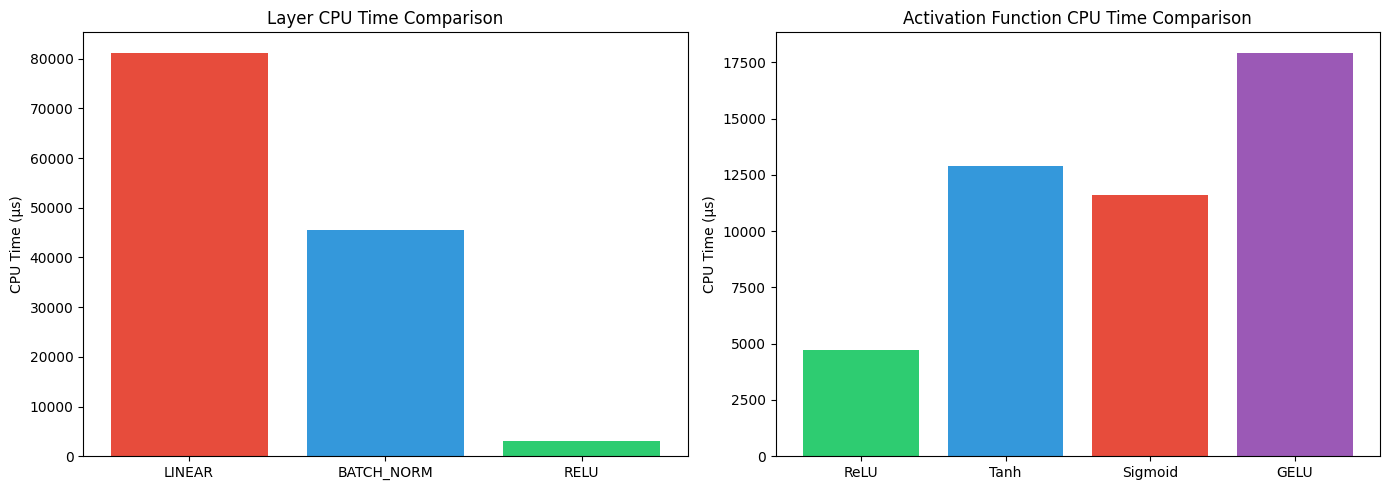

In [22]:
import matplotlib.pyplot as plt

# Layer comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CPU Time
layers = ['LINEAR', 'BATCH_NORM', 'RELU']
cpu_times = [81237.30, 45459.99, 3068.00]
axes[0].bar(layers, cpu_times, color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_ylabel('CPU Time (μs)')
axes[0].set_title('Layer CPU Time Comparison')

# Activation comparison
activations = ['ReLU', 'Tanh', 'Sigmoid', 'GELU']
act_times = [4731.41, 12913.20, 11615.08, 17935.05]
axes[1].bar(activations, act_times, color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])
axes[1].set_ylabel('CPU Time (μs)')
axes[1].set_title('Activation Function CPU Time Comparison')

plt.tight_layout()
plt.savefig('profiling_results.png', dpi=150)
plt.show()

## Section 6: Result Analysis

### 6.1 Layer Comparison Results
- **Linear layers** consume the most CPU time (81.2ms) due to matrix multiplication operations
- **BatchNorm layers** have moderate CPU time (45.5ms) but highest memory usage for storing running statistics
- **ReLU layers** are the fastest (3.1ms) with zero additional memory allocation (inplace operation)

### 6.2 Activation Function Comparison Results
| Rank | Function | CPU Time | Speed Ratio vs ReLU |
|------|----------|----------|---------------------|
| 1 | ReLU | 4.7ms | 1.0x (baseline) |
| 2 | Sigmoid | 11.6ms | 2.5x slower |
| 3 | Tanh | 12.9ms | 2.7x slower |
| 4 | GELU | 17.9ms | 3.8x slower |

### 6.3 Recommendations
- For maximum speed: Use **ReLU** - it's computationally most efficient
- For NLP/Transformers: Use **GELU** despite being slower (better accuracy)
- Memory-constrained: **ReLU** with inplace=True saves memory